# ISyE 6525 HW3 — Question 3: Heat Transfer with CP-ALS

This notebook implements CP-ALS from scratch, as required by the assignment, without calling `cp_als`, TensorLy, or an equivalent decomposition routine.

## Deliverables

- **Q3(a)** Implement CP-ALS. For each of `tensor1`, `tensor2`, and `tensor3`, fit ranks $R=1,\ldots,8$, compute
  $$
  \mathrm{AIC}(R)=2\left\|\mathcal X-\sum_{r=1}^R \lambda_r a_r\circ b_r\circ c_r\right\|_F^2+2R,
  $$
  plot AIC versus rank, and report the minimizing rank.
- **Q3(b)** At the selected rank for `tensor1`, plot the temporal loadings $c_r$ and the leading spatial patterns $\lambda_r a_r\circ b_r$. Interpret them physically.
- **Q3(c)** Determine whether `tensor3` corresponds to material 1 or material 2 using quantities derived from the CP factors. State exactly what is compared and why.

In [15]:
from pathlib import Path
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

np.set_printoptions(precision=5, suppress=True)

DATA_PATH = Path("heatT.mat")
RANKS = range(1, 9)
SEED = 25
MAX_ITER = 500
TOL = 1e-8

# Optional: because CP-ALS uses random initialization and can reach different local minima.
N_RESTARTS = 3


## 1. Load and inspect the heat-transfer tensors

4. Display a few time frames before doing any factorization. This catches axis-order mistakes early.


In [ ]:
mat = loadmat(DATA_PATH)
print("MAT keys:", [k for k in mat.keys() if not k.startswith("__")])

tensor1 = np.asarray(mat["tensor1"], dtype=float)
tensor2 = np.asarray(mat["tensor2"], dtype=float)
tensor3 = np.asarray(mat["tensor3"], dtype=float)

for name, X in {"tensor1": tensor1, "tensor2": tensor2, "tensor3": tensor3}.items():
    print(name, X.shape, X.dtype, "min/max:", X.min(), X.max())
    assert X.shape == (21, 21, 10), f"Unexpected shape for {name}: {X.shape}"


MAT keys: ['tensor1', 'tensor2', 'tensor3']
tensor1 (21, 21, 10) float64 min/max: -0.0513963231074558 1.0205862845417446
tensor2 (21, 21, 10) float64 min/max: 0.008626124315785313 1.0492322056294945
tensor3 (21, 21, 10) float64 min/max: -0.04823357206516501 1.024715289724924


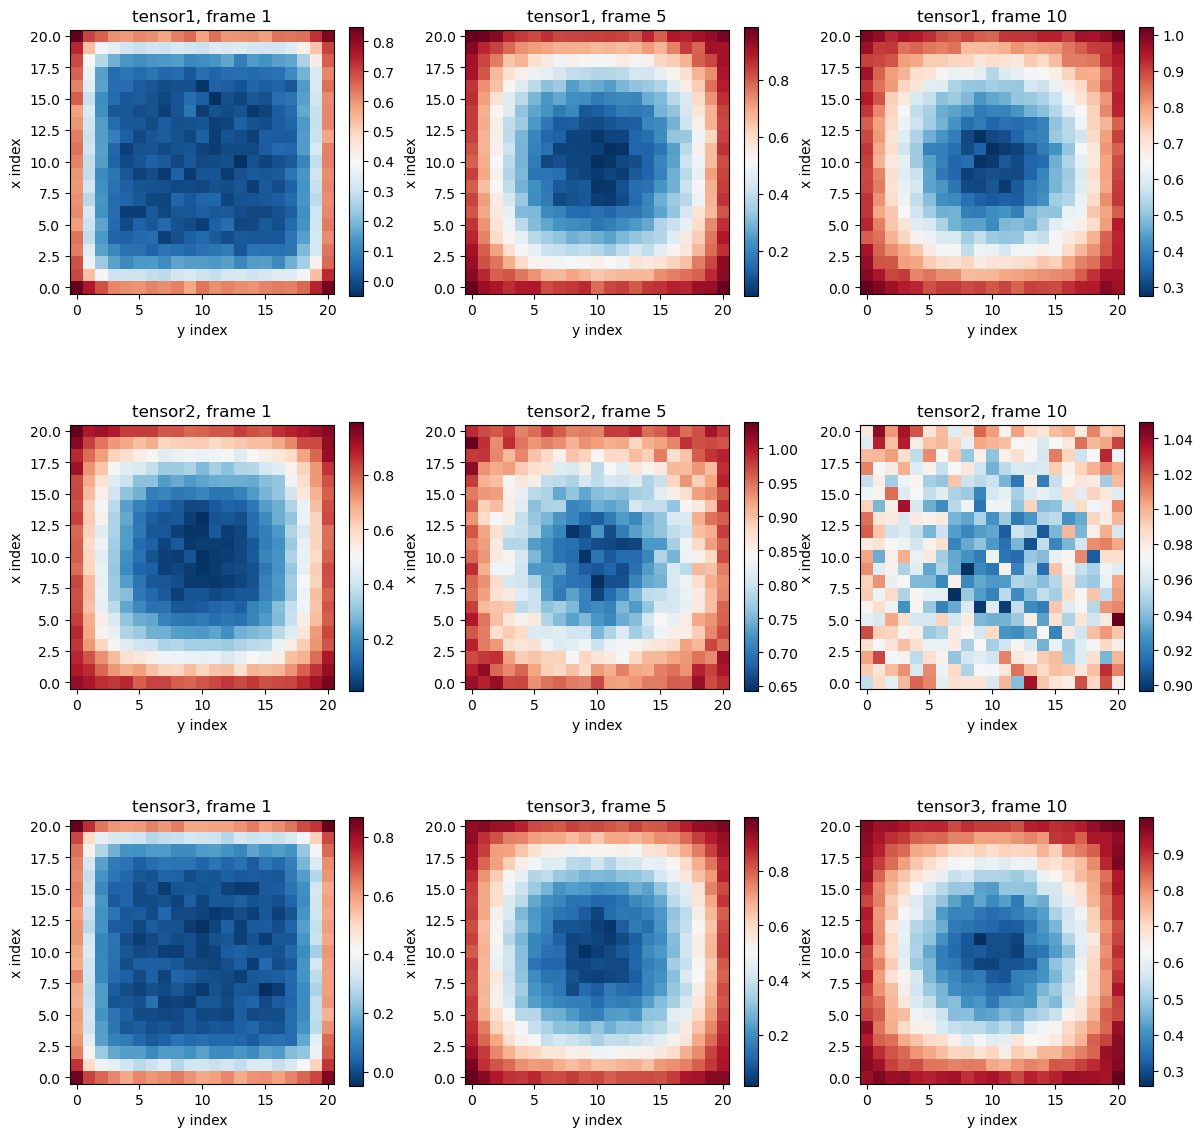

In [ ]:
frames = [0, 4, 9]  # Python indices for time frames 1, 5, 10

fig, axes = plt.subplots(3, len(frames), figsize=(12, 12))
for i, tensor in enumerate([tensor1, tensor2, tensor3]):
    for j, k in enumerate(frames):
        ax = axes[i, j]
        im = ax.imshow(tensor[:, :, k], origin="lower", cmap="RdBu_r")

        ax.set_title(f"tensor{i + 1}, frame {k + 1}")
        ax.set_xlabel("y index")
        ax.set_ylabel("x index")
        fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()


## 2. Build the tensor primitives first

For a third-order tensor $\mathcal X\in\mathbb R^{I\times J\times K}$, choose **one unfolding convention and keep it consistent**.

With the convention used in the lecture,
$$
X_{(1)} \approx A\Lambda(C\odot B)^\top,
$$
so the Khatri-Rao ordering matters.

You need three small primitives:

1. `unfold(X, mode)`
2. `khatri_rao(A, B)`
3. `cp_reconstruct(weights, factors)`

Do not start CP-ALS until these pass tiny synthetic tests.


In [16]:
def unfold(X: np.ndarray, mode: int) -> np.ndarray:
    """Mode-n unfolding.

    Target shape:
        X.shape = (I0, I1, I2)
        output.shape = (X.shape[mode], product(other dimensions))
    
    """
    X_mode = np.moveaxis(X, mode, 0)
    return X_mode.reshape(X.shape[mode], -1)


def khatri_rao(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Column-wise Kronecker product.

    If A is (I, R) and B is (J, R), return (I*J, R), with column r:
        kron(A[:, r], B[:, r]).

    # A: shape (I, R) -> reshape to (I, 1, R)
    # B: shape (J, R) -> reshape to (1, J, R)
    # Element-wise multiplication broadcasts to (I, J, R)
    """
    out = A[:, None, :] * B[None, :, :]
    # Flatten the first two dimensions back into a 2D matrix
    R = A.shape[1]
    return out.reshape(-1, R)


def cp_reconstruct(weights: np.ndarray, factors: list[np.ndarray]) -> np.ndarray:
    """Reconstruct sum_r lambda_r * a_r o b_r o c_r.

    factors = [A, B, C] with shapes (I,R), (J,R), (K,R).

    """
    A, B, C = factors
    I, J, K = A.shape[0], B.shape[0], C.shape[0]
    R = A.shape[1]
    X_hat = np.zeros((I, J, K))
    for r in range(R):
        X_hat += weights[r] * np.einsum('i,j,k->ijk', A[:, r], B[:, r], C[:, r])
    return X_hat


### 2.1 Synthetic tests

Before touching the homework data, make a tensor whose CP representation you know exactly.

If
$$
\mathcal X = 2a_1\circ b_1\circ c_1 - 0.5a_2\circ b_2\circ c_2,
$$
then reconstruction from those exact factors should have numerical error near machine precision.

Also verify the matricized CP identity for **your** unfolding convention. This is the critical test for Khatri-Rao ordering.


In [14]:
rng = np.random.default_rng(SEED)
I, J, K, R = 3, 4, 5, 2
A = rng.normal(size=(I, R))
B = rng.normal(size=(J, R))
C = rng.normal(size=(K, R))
w = np.array([2.0, -0.5])

X_syn = cp_reconstruct(w, [A, B, C])
assert X_syn.shape == (I, J, K)

# Check one unfolding identity. Depending on your unfold convention,
# you may need C ⊙ B versus B ⊙ C. Determine it empirically and then keep it fixed.

lhs = unfold(X_syn, 0)
rhs_candidate_1 = (A * w) @ khatri_rao(C, B).T
rhs_candidate_2 = (A * w) @ khatri_rao(B, C).T

print("candidate C⊙B error:", np.linalg.norm(lhs - rhs_candidate_1))
print("candidate B⊙C error:", np.linalg.norm(lhs - rhs_candidate_2))


candidate C⊙B error: 10.120120040498213
candidate B⊙C error: 4.004243828756106e-16


## 3. Implement CP-ALS

In [25]:
def normalize_columns(M: np.ndarray, eps: float = 1e-12):
    """Return normalized columns and their norms."""
    norm = np.linalg.norm(M, axis=0) + eps
    return M / norm, norm


def cp_als(
    X: np.ndarray,
    rank: int,
    *,
    max_iter: int = MAX_ITER,
    tol: float = TOL,
    seed: int = SEED,
    verbose: bool = False,
):
    """CP-ALS implemented from scratch.

    Returns
    -------
    weights : (R,)
    factors : [A1, A2, A3, ...]
    history : dict containing squared residual per iteration

    Implementation
    --------------
    For each mode, form the Khatri-Rao product of the other factors using
    the unfolding convention established by the synthetic test. The normal
    equations use the Hadamard product of the other Gram matrices. Each
    updated factor is column-normalized, its column norms are stored as the
    component weights, and convergence is monitored using relative change
    in the reconstruction SSE.

    CP factors have permutation/sign/scaling ambiguities. Correctness is
    assessed through reconstruction, not by matching factor columns across
    different runs.
    """
    rng = np.random.default_rng(seed)

    A = []
    weights = np.ones(rank)
    for dim in X.shape:
        A.append(rng.normal(size=(dim, rank)))

    history = {"sse": []}
    for iteration in range(max_iter):
        for k in range(X.ndim):
            grams = [A[j].T @ A[j] for j in range(X.ndim) if j != k]
            V = reduce(np.multiply, grams)
            Z = reduce(khatri_rao, [A[j] for j in range(X.ndim) if j != k])
            A[k] = unfold(X, k) @ Z @ np.linalg.pinv(V)
            A[k], norm = normalize_columns(A[k])
            weights = norm
        X_hat = cp_reconstruct(weights, A)
        sse = np.sum((X - X_hat) ** 2)
        history["sse"].append(sse)
        if verbose:
            print(f"Iteration {iteration}, SSE: {sse}")
        if iteration > 0 and abs(history["sse"][-2] - sse) / history["sse"][-2] < tol:
            break

    return weights, A, history

## 4. Validate CP-ALS on synthetic data

Do not run the rank sweep until this works.

Recommended checks:

- Rank-1 exact tensor should reconstruct almost exactly with `rank=1`.
- Rank-2 synthetic tensor should reconstruct very accurately with `rank=2`.
- SSE should generally decrease across ALS sweeps.
- `cp_reconstruct(weights, factors)` must have the original tensor shape.


synthetic relative error: 3.2489660700446074e-16


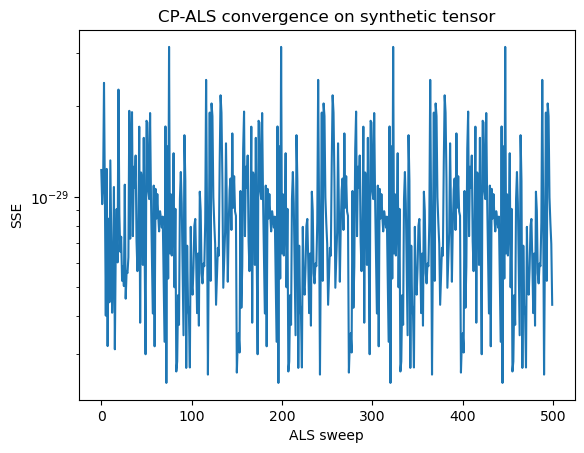

In [26]:
rng = np.random.default_rng(SEED)

weights, factors, history = cp_als(X_syn, rank=2, seed=SEED)
X_hat = cp_reconstruct(weights, factors)
rel_err = np.linalg.norm(X_syn - X_hat) / np.linalg.norm(X_syn)
print("synthetic relative error:", rel_err)

plt.plot(history["sse"])
plt.yscale("log")
plt.xlabel("ALS sweep")
plt.ylabel("SSE")
plt.title("CP-ALS convergence on synthetic tensor")
plt.show()


## 5. Q3(a): rank sweep and AIC

The assignment's criterion is
$$
\mathrm{AIC}(R)=2\|\mathcal X-\hat{\mathcal X}_R\|_F^2+2R.
$$

For each of the three tensors and each $R=1,\ldots,8$:

1. Fit CP-ALS.
2. Compute $\hat{\mathcal X}_R$.
3. Compute SSE.
4. Compute AIC exactly as stated above.
5. Save the best fit/factors for later parts.
6. Select the rank with minimum AIC.

Because random initialization can matter, the scaffold includes `N_RESTARTS`. Keep the fit with the smallest SSE for each rank.


In [27]:
def fit_best_cp_restart(X, rank, n_restarts=N_RESTARTS):
    """Run CP-ALS several times and keep the fit with minimum SSE."""
    best = None
    for restart in range(n_restarts):
        weights, factors, history = cp_als(X, rank, seed=SEED + restart)
        sse = history["sse"][-1]
        if best is None or sse < best["sse"]:
            best = dict(weights=weights, factors=factors, sse=sse, history=history, X_hat=cp_reconstruct(weights, factors))
    return best


def cp_aic(sse: float, rank: int) -> float:
    # Assignment definition — do not silently replace this by another AIC convention.
    return 2.0 * sse + 2.0 * rank


In [28]:
tensors = {
    "tensor1": tensor1,
    "tensor2": tensor2,
    "tensor3": tensor3,
}

results = {}
for name, X in tensors.items():
    results[name] = {}
    for R in RANKS:
        fit = fit_best_cp_restart(X, R)
        fit["aic"] = cp_aic(fit["sse"], R)
        results[name][R] = fit

selected_rank = {
    name: min(per_rank, key=lambda R: per_rank[R]["aic"])
    for name, per_rank in results.items()
}
print("Selected ranks:", selected_rank)


Selected ranks: {'tensor1': 3, 'tensor2': 2, 'tensor3': 3}


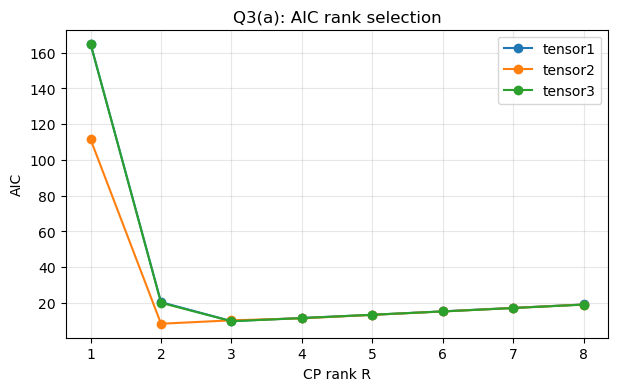

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, per_rank in results.items():
    ranks = list(per_rank)
    aics = [per_rank[R]["aic"] for R in ranks]
    ax.plot(ranks, aics, marker="o", label=name)
ax.set_xlabel("CP rank R")
ax.set_ylabel("AIC")
ax.set_title("Q3(a): AIC rank selection")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 6. Q3(b): temporal loadings and spatial patterns for tensor1

At the selected rank, each CP component can be read as
$$
\lambda_r a_r\circ b_r\circ c_r,
$$
where $\lambda_r a_r b_r^\top$ is a fixed spatial pattern and $c_r(t)$ controls how strongly that pattern contributes at each time frame.

### Physical interpretation

The three selected components separate a persistent spatial background from transient diffusion effects.

- **Component 1** has an almost constant temporal loading (roughly around 0.3) and a smooth, nearly symmetric spatial pattern with a boundary-to-center gradient. It therefore acts mainly as the persistent boundary-driven background temperature profile.
- **Component 2** has a temporal loading that rises rapidly and then levels off. Its spatial pattern provides a second correction to the boundary-versus-interior structure, capturing part of the evolving temperature gradient that cannot be represented by the first component alone.
- **Component 3** is strongly concentrated in the interior and has the largest temporal change: its loading moves from strongly negative at early frames to positive later. In the joint component $\lambda_3 a_3 b_3^\top c_3(t)$, this corresponds to the initially colder interior progressively warming as heat diffuses inward from the hot boundaries.

The signs of individual CP factors are not physically meaningful by themselves because a sign can be moved between factors without changing the reconstructed tensor. The physically meaningful object is the full joint component $\lambda_r a_r\circ b_r\circ c_r$.

Overall, the factors are consistent with diffusion toward equilibrium: a relatively stable boundary-driven spatial profile is supplemented by transient modes whose contribution changes as the interior heats up.

In [39]:
R1 = selected_rank["tensor1"]
fit1 = results["tensor1"][R1]
weights1 = fit1["weights"].copy()
A1, B1, C1 = [F.copy() for F in fit1["factors"]]

order = np.argsort(-np.abs(weights1))
weights1 = weights1[order]
A1, B1, C1 = A1[:, order], B1[:, order], C1[:, order]


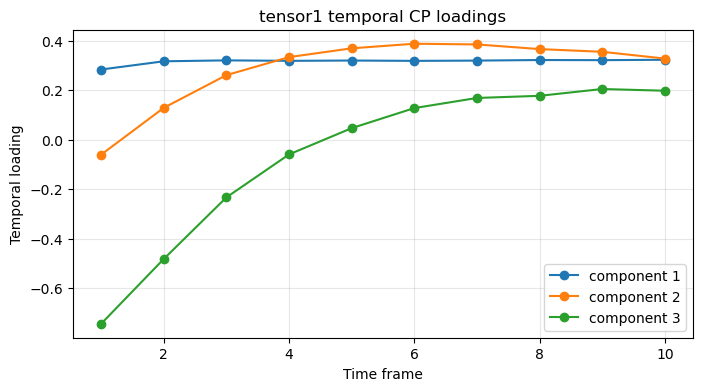

In [40]:
t = np.arange(1, 11)
fig, ax = plt.subplots(figsize=(8, 4))
for r in range(R1):
    ax.plot(t, C1[:, r], marker="o", label=f"component {r+1}")
ax.set_xlabel("Time frame")
ax.set_ylabel("Temporal loading")
ax.set_title("tensor1 temporal CP loadings")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


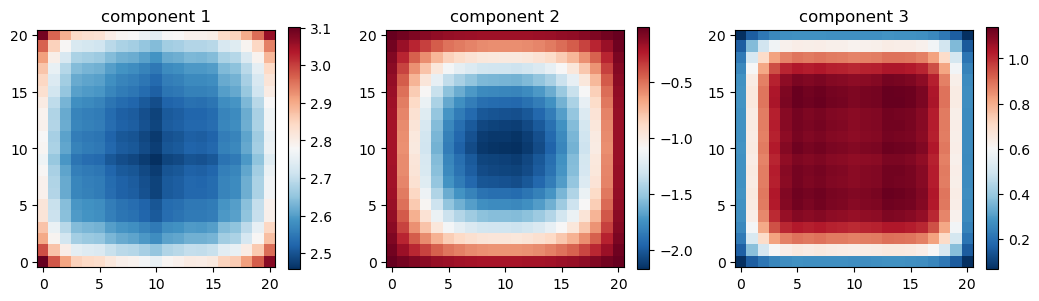

In [41]:
n_show = min(R1, 6)
fig, axes = plt.subplots(1, n_show, figsize=(3.5*n_show, 3.5), squeeze=False)
for r in range(n_show):
    spatial = weights1[r] * np.outer(A1[:, r], B1[:, r])
    ax = axes[0, r]
    im = ax.imshow(spatial, origin="lower", cmap="RdBu_r")
    ax.set_title(f"component {r+1}")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()


## 7. Q3(c): identify tensor3 using CP-derived dynamics

The physical difference between the two materials is the thermal diffusivity $\alpha$, so a useful discriminating quantity should summarize **how the temperature field evolves over time**.

A robust quantity derived directly from the CP factors is the mean reconstructed temperature trajectory:
$$
\bar S(t)
=
\frac{1}{IJ}\sum_{i,j}\hat X_{ijt}
=
\sum_r \lambda_r\,\overline{a_r}\,\overline{b_r}\,c_r(t).
$$

This quantity is appropriate because:

- it is computed directly from the fitted CP factors;
- it is invariant to permutation of CP components;
- it is unaffected by the usual CP sign/scaling rearrangements as long as the reconstruction is unchanged; and
- it has a direct physical interpretation as the overall heating trajectory.

For each tensor, the trajectory is computed at its AIC-selected rank. I then compare tensor3 with tensor1 and tensor2 using the RMSE between their CP-derived mean temperature trajectories. A smaller RMSE means that the two specimens have more similar temporal heating dynamics.

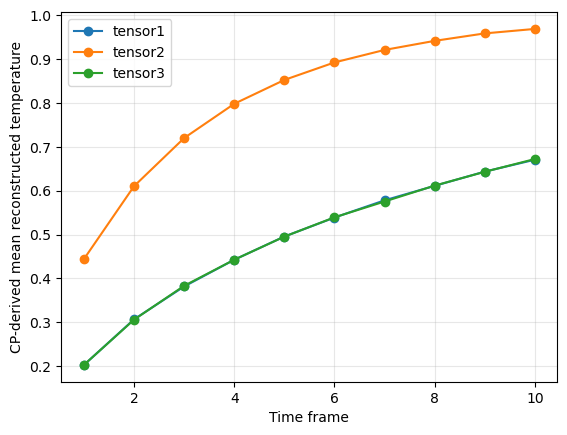

RMSE(tensor3, material1): 0.001163982518743194
RMSE(tensor3, material2): 0.325389681502026


In [42]:
def cp_mean_trajectory(weights, factors):
    """Mean over spatial modes computed directly from CP factors."""
    A, B, C = factors
    spatial_scale = weights * A.mean(axis=0) * B.mean(axis=0)
    return C @ spatial_scale


# Compute and compare selected-rank trajectories.

trajectories = {}
for name in tensors:
    R = selected_rank[name]
    fit = results[name][R]
    trajectories[name] = cp_mean_trajectory(fit["weights"], fit["factors"])

for name, y in trajectories.items():
    plt.plot(np.arange(1, 11), y, marker="o", label=name)
plt.xlabel("Time frame")
plt.ylabel("CP-derived mean reconstructed temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

d31 = np.sqrt(np.mean((trajectories["tensor3"] - trajectories["tensor1"])**2))
d32 = np.sqrt(np.mean((trajectories["tensor3"] - trajectories["tensor2"])**2))
print("RMSE(tensor3, material1):", d31)
print("RMSE(tensor3, material2):", d32)


### Q3(c) conclusion

The CP-derived mean temperature trajectory of `tensor3` is much closer to that of material 1 than material 2:
$$
\operatorname{RMSE}(\text{tensor3},\text{material 1}) \approx 0.001164,
$$
whereas
$$
\operatorname{RMSE}(\text{tensor3},\text{material 2}) \approx 0.325390.
$$

Therefore,
$$
\boxed{\text{tensor3 corresponds to material 1}.}
$$

Thermal diffusivity controls the rate at which the temperature field evolves. Since tensor3 and material 1 have nearly identical CP-derived mean heating trajectories, their fitted temporal diffusion behavior is consistent with the same material class.